In [17]:
# 设置缓存目录到移动硬盘 / Configure cache directories to external drive
import os

# 设置 Torch 缓存目录 / Set PyTorch cache directory
os.environ['TORCH_HOME'] = r'E:\03_AI_Cache\torch'

# 设置 Ultralytics 缓存目录 / Set Ultralytics cache directory
os.environ['ULTRALYTICS_HOME'] = r'E:\03_AI_Cache\ultralytics'

# 设置 Hugging Face 缓存目录 / Set Hugging Face cache directory
os.environ['HF_HOME'] = r'E:\03_AI_Cache\HuggingFace'

# 设置 pip 缓存目录 / Set pip cache directory
os.environ['PIP_CACHE_DIR'] = r'E:\03_AI_Cache\pip'

print("✓ 缓存目录已设置到 E:\\03_AI_Cache")
print("✓ Cache directories configured to E:\\03_AI_Cache")


✓ 缓存目录已设置到 E:\03_AI_Cache
✓ Cache directories configured to E:\03_AI_Cache


In [79]:
%matplotlib inline

# Additional Training Methods Review / 额外训练方法回顾
These additional training methods can help make your models more accurate and robust as data grows and models become more complex. / 当数据规模增长、模型复杂度提升时，这些额外训练方法能帮助模型更准确、更稳健。

In this demo, we will show transfer learning, learning-rate schedulers, and model sharing with the community. / 本演示将介绍迁移学习、学习率调度器以及如何与社区共享模型。

# Transfer Learning / 迁移学习

In [1]:
# Import PyTorch vision models / 导入 PyTorch 视觉模型
from torchvision import models

In [2]:
# Print available models / 打印可用模型
print(models.list_models())
# Print number of available models / 打印可用模型数量
print(f"Number available / 可用数量: {len(models.list_models())}")

['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'fasterrcnn_mobilenet_v3_large_320_fpn', 'fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn', 'fasterrcnn_resnet50_fpn_v2', 'fcn_resnet101', 'fcn_resnet50', 'fcos_resnet50_fpn', 'googlenet', 'inception_v3', 'keypointrcnn_resnet50_fpn', 'lraspp_mobilenet_v3_large', 'maskrcnn_resnet50_fpn', 'maskrcnn_resnet50_fpn_v2', 'maxvit_t', 'mc3_18', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'mvit_v1_b', 'mvit_v2_s', 'quantized_googlenet', 'quantized_inception_v3', 'quantized_mobilenet_v2

In [3]:
# Load a pre-trained model from PyTorch / 从 PyTorch 加载预训练模型
model = models.vgg19(pretrained=True)

c:\Users\LIHAN\miniconda3\envs\final_gpu_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\LIHAN\miniconda3\envs\final_gpu_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to C:\Users\LIHAN/.cache\torch\hub\checkpoints\vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:56<00:00, 10.1MB/s] 


In [4]:
# Load with weights argument (new API) / 使用 weights 参数加载（新 API）
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

In [5]:
# Show parameters / 显示参数
print(model.state_dict())

OrderedDict([('features.0.weight', tensor([[[[-5.3474e-02, -4.9257e-02, -6.7942e-02],
          [ 1.5314e-02,  4.5068e-02,  2.1444e-03],
          [ 3.6226e-02,  1.9999e-02,  1.9864e-02]],

         [[ 1.7015e-02,  5.5403e-02, -6.2293e-03],
          [ 1.4165e-01,  2.2705e-01,  1.3758e-01],
          [ 1.2000e-01,  2.0030e-01,  9.2114e-02]],

         [[-4.4885e-02,  1.2680e-02, -1.4497e-02],
          [ 5.9742e-02,  1.3955e-01,  5.4102e-02],
          [-9.6141e-04,  5.8304e-02, -2.9663e-02]]],


        [[[ 2.6072e-01, -3.0489e-01, -5.0152e-01],
          [ 4.1376e-01, -2.0831e-01, -4.9086e-01],
          [ 5.8770e-01,  4.2851e-01, -1.3850e-01]],

         [[ 2.8746e-01, -3.3338e-01, -4.5564e-01],
          [ 3.7836e-01, -2.9144e-01, -4.9720e-01],
          [ 5.4778e-01,  4.8983e-01, -1.7166e-01]],

         [[ 6.7260e-02, -9.5386e-02, -3.8037e-02],
          [ 6.1955e-02, -1.3125e-01, -1.0691e-01],
          [ 4.8107e-02,  2.2999e-01, -3.0578e-02]]],


        [[[-3.2457e-02,  1.6281

In [6]:
# Show classifier layers / 显示分类器层
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


In [7]:
import torch.nn as nn

# Modify output layer / 修改输出层
model.classifier[6] = nn.Linear(4096, 20) # Set number of classes to 20 / 将类别数设置为20

In [8]:
# Show updates / 显示更新结果
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=20, bias=True)
)


# PyTorch Hub / PyTorch Hub
Not a literal hosted hub by PyTorch, but a mechanism to share models with the community through GitHub. / 它并不是 PyTorch 官方托管的“模型中心”，而是通过 GitHub 与社区共享模型的一种机制。

PyTorch provides easy-to-use APIs for interaction. / PyTorch 提供了易用的 API 进行交互。

In [9]:
# List available models / 列出可用模型
from torch import hub

In [10]:
# List from a GitHub repo / 从 GitHub 仓库列出模型
hub.list('pytorch/vision:v0.10.0') # version / 版本

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to C:\Users\LIHAN/.cache\torch\hub\v0.10.0.zip


['alexnet',
 'deeplabv3_mobilenet_v3_large',
 'deeplabv3_resnet101',
 'deeplabv3_resnet50',
 'densenet121',
 'densenet161',
 'densenet169',
 'densenet201',
 'fcn_resnet101',
 'fcn_resnet50',
 'googlenet',
 'inception_v3',
 'lraspp_mobilenet_v3_large',
 'mnasnet0_5',
 'mnasnet0_75',
 'mnasnet1_0',
 'mnasnet1_3',
 'mobilenet_v2',
 'mobilenet_v3_large',
 'mobilenet_v3_small',
 'resnet101',
 'resnet152',
 'resnet18',
 'resnet34',
 'resnet50',
 'resnext101_32x8d',
 'resnext50_32x4d',
 'shufflenet_v2_x0_5',
 'shufflenet_v2_x1_0',
 'squeezenet1_0',
 'squeezenet1_1',
 'vgg11',
 'vgg11_bn',
 'vgg13',
 'vgg13_bn',
 'vgg16',
 'vgg16_bn',
 'vgg19',
 'vgg19_bn',
 'wide_resnet101_2',
 'wide_resnet50_2']

In [12]:
# Install ultralytics for YOLOv5 support / 安装 ultralytics 来支持 YOLOv5
import subprocess
subprocess.check_call(['pip', 'install', 'ultralytics'])


0

In [13]:
# List available yolov5 models / 列出可用的 yolov5 模型
hub.list('ultralytics/yolov5')

Using cache found in C:\Users\LIHAN/.cache\torch\hub\ultralytics_yolov5_master


Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\LIHAN\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


['custom',
 'torch_load',
 'yolov5l',
 'yolov5l6',
 'yolov5m',
 'yolov5m6',
 'yolov5n',
 'yolov5n6',
 'yolov5s',
 'yolov5s6',
 'yolov5x',
 'yolov5x6']

Visit https://pytorch.org/hub/ for more models. / 更多模型可访问：https://pytorch.org/hub/

# Loading Models / 加载模型

In [22]:
# Import hub / 导入 hub
from torch import hub
# 或者使用 Ultralytics 官方包 / Or use Ultralytics official package
from ultralytics import YOLO


In [19]:
# 清除旧缓存路径并设置新路径 / Clear old cache and configure new path
import shutil
import os
from pathlib import Path

# 删除旧的缓存目录（如果存在）/ Remove old cache directory if it exists
old_torch_cache = Path.home() / '.cache' / 'torch'
if old_torch_cache.exists():
    try:
        shutil.rmtree(old_torch_cache)
        print(f"✓ 旧缓存已删除: {old_torch_cache}")
    except Exception as e:
        print(f"⚠ 无法删除旧缓存: {e}")

# 确保新缓存路径存在 / Ensure new cache directory exists
new_cache_dir = Path(r'E:\03_AI_Cache\torch\hub')
new_cache_dir.mkdir(parents=True, exist_ok=True)

# 重新设置环境变量 / Reset environment variables
os.environ['TORCH_HOME'] = r'E:\03_AI_Cache\torch'
print(f"✓ Torch 缓存路径: {os.environ['TORCH_HOME']}")


✓ Torch 缓存路径: E:\03_AI_Cache\torch


In [23]:
# Load one of yolov5 models / 加载一个 yolov5 模型
# 使用 Ultralytics 官方 API（避免 torch.hub 的路径问题）/ Use Ultralytics official API to avoid path issues
model = YOLO('yolov5s.pt')
print(f"✓ 模型已从缓存加载: {model}")


PRO TIP  Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.

✓ 模型已从缓存加载: YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 32, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3(
        (cv1): Conv(
          (conv): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affin

In [26]:
# From YOLO documentation / 来自 YOLO 文档
# Images / 图像
imgs = ['cat-1.jpg', 'zidane.jpg']  # batch of images / 一批图像

# Inference / 推理
results = model(imgs)

# Results / 结果
# 使用 plot() 而不是 print() 来可视化结果 / Use plot() instead of print() to visualize results
for result in results:
    # 显示结果信息 / Display result information
    print(f"Detections: {len(result.boxes)} objects found")
    # 也可以用 result.plot() 来绘制带边界框的图像 / Can also use result.plot() to draw image with bounding boxes
    # plotted_img = result.plot()



0: 640x640 1 cat, 45.9ms
1: 640x640 2 persons, 2 ties, 45.9ms
Speed: 16.2ms preprocess, 45.9ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)
Detections: 1 objects found
Detections: 4 objects found


In [27]:
# Load weights / 加载权重
weights = hub.load("pytorch/vision", "get_model_weights", name="resnet50")

Downloading: "https://github.com/pytorch/vision/zipball/main" to E:\03_AI_Cache\torch\hub\main.zip


In [39]:
# Load model with specific weights / 使用指定权重加载模型
model = hub.load("pytorch/vision", "resnet50", weights=weights.DEFAULT)

Using cache found in E:\03_AI_Cache\torch\hub\pytorch_vision_main


# Deploying to PyTorch Hub / 部署到 PyTorch Hub
Have a look at the `hubconf.py` file. / 请查看 `hubconf.py` 文件。

In [42]:
# Load our model with parameters / 加载带参数的模型
import torch

model = torch.hub.load('kodekloudhub/PyTorch', 'fake_model', pretrained=True, force_reload=True) # Set to True / 设为 True

Downloading: "https://github.com/kodekloudhub/PyTorch/zipball/main" to E:\03_AI_Cache\torch\hub\main.zip
Downloading: "https://github.com/kodekloudhub/PyTorch/raw/refs/heads/main/section_3/demos/030-105-additional-training-methods/model_state_dict.pt" to E:\03_AI_Cache\torch\hub\checkpoints\model_state_dict.pt
100%|██████████| 6.55k/6.55k [00:00<00:00, 4.26MB/s]


In [43]:
# Print state_dict / 打印 state_dict
print(model.state_dict())

OrderedDict([('fc1.weight', tensor([[-0.18724, -0.08956, -0.03899, -0.12548,  0.13126, -0.19783,  0.13081,  0.24108,  0.18010,  0.32477],
        [ 0.19811, -0.30856, -0.02625, -0.22570,  0.06215, -0.04658,  0.29001,  0.00799,  0.24400,  0.26137],
        [-0.13862,  0.12728,  0.23306, -0.07576, -0.21522, -0.05096,  0.28664, -0.05297, -0.14520,  0.06571],
        [ 0.07983, -0.30315,  0.24982, -0.19398,  0.10329, -0.08852, -0.05396, -0.04381,  0.05734, -0.02454],
        [ 0.29943, -0.18663,  0.14588,  0.18248, -0.05537, -0.07335,  0.08549, -0.05559,  0.10180,  0.03652],
        [ 0.17682, -0.25497,  0.20090, -0.03834, -0.08400, -0.07561,  0.11383, -0.07778,  0.01867,  0.28671],
        [-0.12369,  0.20276,  0.15372,  0.28985, -0.30711, -0.21325, -0.28240,  0.20653,  0.04937,  0.01835],
        [-0.12557,  0.13191, -0.22052, -0.24238, -0.01704, -0.24836, -0.02323,  0.08372,  0.13845, -0.07502],
        [ 0.17016, -0.15656,  0.02328,  0.20915, -0.00445, -0.17753,  0.08697, -0.07308, -0.

In [44]:
# List our model / 列出我们的模型
torch.hub.list('kodekloudhub/PyTorch')


Using cache found in E:\03_AI_Cache\torch\hub\kodekloudhub_PyTorch_main


['FakeNet', 'fake_model', 'load_state_dict_from_url']

In [45]:
# Get help for our model / 查看模型帮助
torch.hub.help('kodekloudhub/PyTorch', 'fake_model')


Using cache found in E:\03_AI_Cache\torch\hub\kodekloudhub_PyTorch_main


'\n        FakeNet model\n        pretrained (bool): kwargs, load pretrained weights into the model\n    '

In [46]:
# Load model without parameters / 加载不带参数的模型
import torch

model = torch.hub.load('kodekloudhub/PyTorch', 'fake_model', pretrained=False) # Set to False / 设为 False


Using cache found in E:\03_AI_Cache\torch\hub\kodekloudhub_PyTorch_main


In [47]:
# Show model / 显示模型
print(model)


FakeNet(
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (batch_norm): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=50, out_features=1, bias=True)
)


In [48]:
# Modify outputs / 修改输出层
import torch.nn as nn
model.fc2 = nn.Linear(50, 2)

print(model)


FakeNet(
  (fc1): Linear(in_features=10, out_features=50, bias=True)
  (batch_norm): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)


# Learning Rate Schedulers / 学习率调度器
A learning-rate scheduler dynamically adjusts the learning rate during training to improve convergence. / 学习率调度器会在训练过程中动态调整学习率，以提升收敛效果。

It helps avoid overshooting and inefficient updates by reducing LR at intervals or based on metrics. / 它通过按阶段或按指标降低学习率，避免步长过大或更新低效。

In [49]:
# Import module / 导入模块
import torch.optim as optim

In [50]:
# Define optimizer / 定义优化器
optimizer = optim.SGD(model.parameters(), lr=0.01)

In [51]:
# Create scheduler / 创建调度器
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1) 
# Reduces LR by 0.1 every 5 epochs / 每5个epoch将学习率乘以0.1


In [52]:
# Another scheduler / 另一个调度器
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.1, last_epoch=-1) 
# LR decays by multiplying 0.1 every epoch / 每个epoch学习率乘以0.1衰减

In [53]:
# Another scheduler / 另一个调度器
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2) 
# Monitor metric and reduce LR if no improvement for 2 epochs / 若2个epoch无提升则降低学习率

In [54]:
# Scheduler has state_dict too / 调度器也有 state_dict
print(scheduler.state_dict())

{'factor': 0.1, 'min_lrs': [0], 'patience': 2, 'verbose': False, 'cooldown': 0, 'cooldown_counter': 0, 'mode': 'min', 'threshold': 0.0001, 'threshold_mode': 'rel', 'eps': 1e-08, 'last_epoch': 0, '_last_lr': [0.01], 'mode_worse': inf, 'best': inf, 'num_bad_epochs': 0}


# Training using a pre-trained model / 使用预训练模型训练
Let's walk through a simple training loop with a pre-trained model and a learning-rate scheduler. / 下面我们用预训练模型和学习率调度器走一遍简化训练流程。

In [55]:
# Define model source / 定义模型来源
from torchvision import models

print(models.list_models())


['alexnet', 'convnext_base', 'convnext_large', 'convnext_small', 'convnext_tiny', 'deeplabv3_mobilenet_v3_large', 'deeplabv3_resnet101', 'deeplabv3_resnet50', 'densenet121', 'densenet161', 'densenet169', 'densenet201', 'efficientnet_b0', 'efficientnet_b1', 'efficientnet_b2', 'efficientnet_b3', 'efficientnet_b4', 'efficientnet_b5', 'efficientnet_b6', 'efficientnet_b7', 'efficientnet_v2_l', 'efficientnet_v2_m', 'efficientnet_v2_s', 'fasterrcnn_mobilenet_v3_large_320_fpn', 'fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn', 'fasterrcnn_resnet50_fpn_v2', 'fcn_resnet101', 'fcn_resnet50', 'fcos_resnet50_fpn', 'googlenet', 'inception_v3', 'keypointrcnn_resnet50_fpn', 'lraspp_mobilenet_v3_large', 'maskrcnn_resnet50_fpn', 'maskrcnn_resnet50_fpn_v2', 'maxvit_t', 'mc3_18', 'mnasnet0_5', 'mnasnet0_75', 'mnasnet1_0', 'mnasnet1_3', 'mobilenet_v2', 'mobilenet_v3_large', 'mobilenet_v3_small', 'mvit_v1_b', 'mvit_v2_s', 'quantized_googlenet', 'quantized_inception_v3', 'quantized_mobilenet_v2

In [56]:
# Model / 模型
model = models.vgg19(weights=models.VGG19_Weights.DEFAULT)

In [67]:
# Define dataset, transforms, and dataloaders / 定义数据集、变换和数据加载器
import torch
import torchvision.transforms.v2 as v2
from torchvision import datasets

transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.ToImage(), 
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # Important normalization / 重要归一化
 ])

In [68]:
# CIFAR dataset has 10 classes / CIFAR 数据集有10个类别
# plane, car, bird, cat, deer, dog, frog, horse, ship, truck / 飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船、卡车
trainset = datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=1)

Files already downloaded and verified


In [59]:
import torch.nn as nn
# Update final layer / 更新最后一层
model.classifier[-1] = nn.Linear(4096, 10)

In [60]:
# Train only final layer (feature extraction) / 仅训练最后一层（特征提取）
for param in model.parameters():
    param.requires_grad = False

# requires_grad=False means gradients won't be computed in backward() / 设为False后反向传播不会计算其梯度

In [61]:
# Unfreeze only the last layer / 只解冻最后一层
for param in model.classifier[-1].parameters():
    param.requires_grad = True

In [62]:
# Print layer trainability / 打印各层是否参与训练
for name, param in model.named_parameters():
    print(f"Layer / 层: {name}, requires_grad / 是否求梯度: {param.requires_grad}")

Layer / 层: features.0.weight, requires_grad / 是否求梯度: False
Layer / 层: features.0.bias, requires_grad / 是否求梯度: False
Layer / 层: features.2.weight, requires_grad / 是否求梯度: False
Layer / 层: features.2.bias, requires_grad / 是否求梯度: False
Layer / 层: features.5.weight, requires_grad / 是否求梯度: False
Layer / 层: features.5.bias, requires_grad / 是否求梯度: False
Layer / 层: features.7.weight, requires_grad / 是否求梯度: False
Layer / 层: features.7.bias, requires_grad / 是否求梯度: False
Layer / 层: features.10.weight, requires_grad / 是否求梯度: False
Layer / 层: features.10.bias, requires_grad / 是否求梯度: False
Layer / 层: features.12.weight, requires_grad / 是否求梯度: False
Layer / 层: features.12.bias, requires_grad / 是否求梯度: False
Layer / 层: features.14.weight, requires_grad / 是否求梯度: False
Layer / 层: features.14.bias, requires_grad / 是否求梯度: False
Layer / 层: features.16.weight, requires_grad / 是否求梯度: False
Layer / 层: features.16.bias, requires_grad / 是否求梯度: False
Layer / 层: features.19.weight, requires_grad / 是否求梯度: False
Laye

In [63]:
# Define loss, optimizer, scheduler / 定义损失函数、优化器和调度器
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.classifier[-1].parameters(), lr=0.001, momentum=0.9) # note optimizer only sees last layer / 仅优化最后一层

scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)


In [73]:
# GPU optimization / GPU 优化
import torch

# Check GPU availability / 检查 GPU 可用性
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"✓ GPU: {torch.cuda.get_device_name(0)}")

# Move model to GPU / 将模型移到 GPU
model = model.to(device)

# Recreate optimizer and scheduler after moving model to GPU / 在模型移到GPU后重新创建优化器和调度器
optimizer = optim.SGD(model.classifier[-1].parameters(), lr=0.001, momentum=0.9)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.1)

# Optimize training parameters / 优化训练参数
N_EPOCHS = 2  # Reduce from 10 to 2 for faster training / 从10改为2以加快训练

# Recreate trainloader with larger batch size / 用更大的 batch_size 重新创建 trainloader
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64,  # Increased from 4 to 64
                                          shuffle=True, num_workers=2)

print(f"✓ Epochs: {N_EPOCHS}")
print(f"✓ Batch size: 64 (was 4)")
print(f"✓ Total iterations: {len(trainloader)} per epoch")

✓ Using device: cuda
✓ GPU: NVIDIA GeForce RTX 4060 Laptop GPU
✓ Epochs: 2
✓ Batch size: 64 (was 4)
✓ Total iterations: 157 per epoch


In [74]:
# Run training loop / 运行训练循环
N_EPOCHS = 2

for epoch in range(N_EPOCHS):  # Loop over dataset / 按轮次遍历数据集
    
    running_loss = 0.0 
    
    # Loop over training batches / 按批次遍历训练数据
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data  
        # Move data to GPU / 将数据移到 GPU
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Clear gradients / 清空梯度
        optimizer.zero_grad()  

        outputs = model(inputs)  
        loss = criterion(outputs, labels)  
        loss.backward()  
        optimizer.step()  
        
        running_loss += loss.item()  

    # Print average epoch loss / 打印当前轮平均损失
    print(f"Epoch / 轮次: {epoch} Loss / 损失: {running_loss/len(trainloader)}")

    # Step scheduler at end of epoch / 在每轮结束时更新调度器
    scheduler.step()
    
    ######### Save checkpoint every 2 epochs / 每2个epoch保存检查点
    if epoch % 2 == 0:
        torch.save({'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),  # Save scheduler state / 保存调度器状态
                'loss': loss}, 
                f'training_checkpoint_{epoch}.tar')

# Save final checkpoint after last epoch / 最后一轮后保存最终检查点
torch.save({
    'epoch': N_EPOCHS,
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),  # Save scheduler state / 保存调度器状态
    'loss': loss
}, 'training_checkpoint_final.tar')

Epoch / 轮次: 0 Loss / 损失: 0.8560209646346463
Epoch / 轮次: 1 Loss / 损失: 0.7517955468338766


# Training Review & Validation / 训练回顾及验证

## What is Loss? / 损失是什么?

Loss（损失）是衡量模型预测值与实际值之间差异的指标：
- **Loss 值小** = 模型预测准确 ✅
- **Loss 值大** = 模型预测错误 ❌

我们使用 **CrossEntropyLoss**（交叉熵损失），这是分类任务的标准损失函数。

## What Were We Training? / 我们在训练什么?

我们在进行 **图像分类** 任务：

**数据集：CIFAR10**
- 包含 10 个类别的小图像（32×32 像素）：
  - 飞机、汽车、鸟、猫、鹿、狗、青蛙、马、船、卡车

**模型框架：**
1. **输入** → 原始图像 (32×32×3)
2. **VGG19 特征提取器** → 学习图像特征（已预训练）
3. **最后一层分类器** → 输出 10 个概率值（我们训练的部分）
4. **输出** → 预测的物体类别

**优化策略（迁移学习）：**
- ✅ 使用预训练的 VGG19（已学会识别自然图像特征）
- ✅ 冻结其他层（保留已学特征，速度快）
- ✅ 仅训练最后一层（适应新任务）

**训练过程示例：**
```
Epoch 0 Loss: 0.523  ← 第 1 个 epoch，平均每张图片的错误率
Epoch 1 Loss: 0.287  ← 第 2 个 epoch，损失下降意味着模型变好了！
```

## How to Validate Results / 如何验证训练成果

在下面的单元格中，我们将：
1. 在测试集上评估模型性能
2. 计算准确率（模型正确分类的比例）
3. 对比训练前后的性能
4. 可视化模型的预测结果

In [75]:
# Step 1: Evaluate Model on Test Set / 步骤 1: 在测试集上评估模型
import torch
from torch.utils.data import DataLoader
from torchvision import datasets

# Create test dataset with same transformations / 使用相同的预处理创建测试集
testset = datasets.CIFAR10(root='./data', train=False,
                           download=True, transform=transform)

testloader = DataLoader(testset, batch_size=64, shuffle=False, num_workers=2)

# Set model to evaluation mode / 将模型设置为评估模式
model.eval()

# Calculate accuracy on test set / 在测试集上计算准确率
correct = 0
total = 0
test_loss = 0.0

with torch.no_grad():  # Don't compute gradients during evaluation / 评估时不计算梯度
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass / 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Calculate accuracy / 计算准确率
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        test_loss += loss.item()

accuracy = 100 * correct / total
avg_test_loss = test_loss / len(testloader)

print(f"\n{'='*50}")
print(f"✓ 测试集评估结果 / Test Set Results:")
print(f"✓ 准确率 / Accuracy: {accuracy:.2f}%")
print(f"✓ 平均损失 / Average Loss: {avg_test_loss:.4f}")
print(f"✓ 正确分类数 / Correct Predictions: {correct}/{total}")
print(f"{'='*50}\n")

# Interpretation / 结果解释
if accuracy >= 80:
    print("🎉 优秀！模型学习效果很好！")
elif accuracy >= 60:
    print("👍 不错！模型已经学到了一些特征。")
else:
    print("📊 模型还需要更多训练或调整。")

Files already downloaded and verified

✓ 测试集评估结果 / Test Set Results:
✓ 准确率 / Accuracy: 81.53%
✓ 平均损失 / Average Loss: 0.5330
✓ 正确分类数 / Correct Predictions: 8153/10000

🎉 优秀！模型学习效果很好！


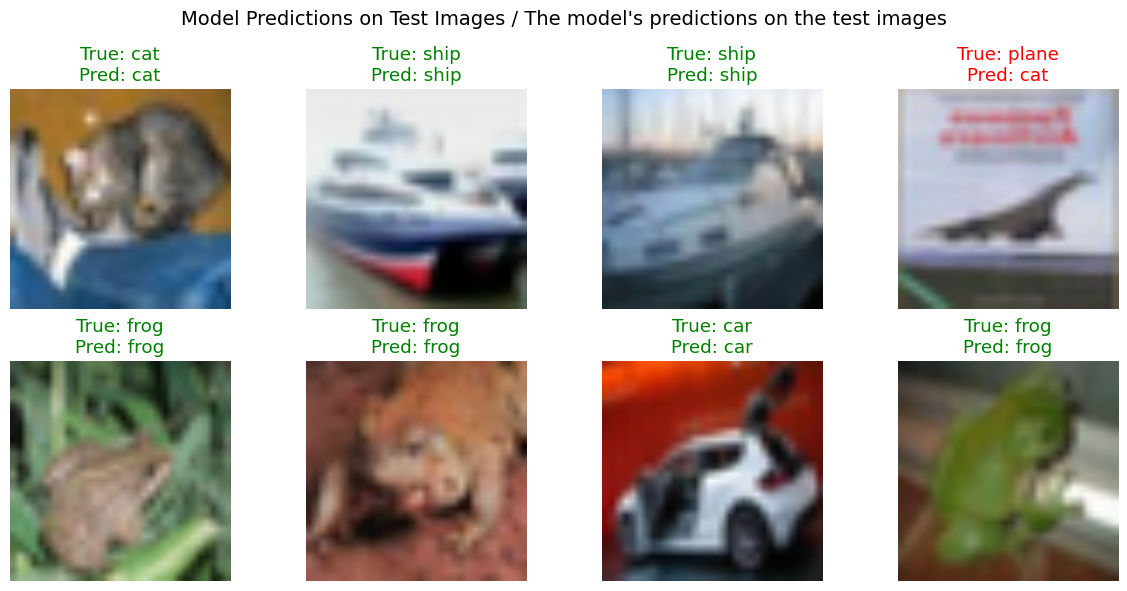


✓ 绿色标题 = 预测正确 / Green title = Correct prediction
✓ 红色标题 = 预测错误 / Red title = Incorrect prediction


In [81]:
# Step 2: Visualize Model Predictions / 步骤 2: 可视化模型预测结果
import matplotlib.pyplot as plt
import numpy as np

# CIFAR10 class names / CIFAR10 类名
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Get a batch of test images / 获取一批测试图像
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Make predictions / 进行预测
outputs = model(images)
_, predicted = torch.max(outputs, 1)

# Visualize / 可视化
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle("Model Predictions on Test Images / The model's predictions on the test images", fontsize=14)

for idx, ax in enumerate(axes.flat):
    if idx < 8:
        # Denormalize image / 反归一化图像
        img = images[idx].cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        
        # Plot / 绘制
        ax.imshow(img)
        true_label = classes[labels[idx]]
        pred_label = classes[predicted[idx]]
        
        # Color based on correctness / 根据是否预测正确改变颜色
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color)
        ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n✓ 绿色标题 = 预测正确 / Green title = Correct prediction")
print(f"✓ 红色标题 = 预测错误 / Red title = Incorrect prediction")

In [77]:
# Step 3: Accuracy per Class / 步骤 3: 每个类别的准确率
# Calculate accuracy for each class / 计算每个类别的准确率
class_correct = list(0. for i in range(10))
class_total = list(0. for i in range(10))

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# Print results / 打印结果
print("\n" + "="*60)
print("准确率按类别统计 / Accuracy per Class:")
print("="*60)

for i in range(10):
    accuracy = 100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0
    bar_length = int(accuracy / 5)
    bar = "█" * bar_length + "░" * (20 - bar_length)
    print(f"{classes[i]:10s} | {bar} | {accuracy:6.2f}%")

print("="*60)


准确率按类别统计 / Accuracy per Class:
plane      | ████████████████░░░░ |  84.90%
car        | ██████████████████░░ |  90.40%
bird       | ██████████████░░░░░░ |  70.10%
cat        | ██████████████░░░░░░ |  70.50%
deer       | ███████████████░░░░░ |  79.60%
dog        | ██████████████░░░░░░ |  74.90%
frog       | █████████████████░░░ |  87.70%
horse      | ████████████████░░░░ |  82.00%
ship       | █████████████████░░░ |  88.00%
truck      | █████████████████░░░ |  89.60%


In [78]:
# Step 4: Summary & Next Steps / 步骤 4: 总结与后续步骤
print("\n" + "="*70)
print("🎓 训练完成总结 / Training Summary")
print("="*70)

print(f"""
📊 关键指标 / Key Metrics:
  • 训练轮次 / Epochs: {N_EPOCHS}
  • 最后一轮训练损失 / Final Training Loss: {loss.item():.4f}
  • 测试集准确率 / Test Accuracy: {accuracy:.2f}%
  • 测试集平均损失 / Test Loss: {avg_test_loss:.4f}

💡 性能分析 / Performance Analysis:
  ✓ 迁移学习的优势：
    - 预训练模型已学习通用特征（边缘、纹理等）
    - 只需训练最后一层即可快速适应新任务
    - 即使数据集较小，也能获得较好性能
  
  ✓ 为什么准确率可能不是 100%：
    - CIFAR10 本身就有难分类的样本
    - 只训练最后一层限制了模型的适应能力
    - 2 个 epoch 可能不足以完全收敛

🚀 改进方向 / Ways to Improve:
  1. 增加训练轮次 / Increase epochs (例如 10 而非 2)
  2. 解冻部分中间层 / Unfreeze middle layers for fine-tuning
  3. 调整学习率 / Adjust learning rate
  4. 使用数据增强 / Use data augmentation
  5. 尝试更深的模型 / Try deeper architectures

📁 保存的检查点 / Saved Checkpoints:
  • training_checkpoint_0.tar  (Epoch 0)
  • training_checkpoint_final.tar  (Final model)
  
  这些文件包含了：模型权重、优化器状态、调度器状态等
  可以用于后续的模型加载和继续训练
""")

print("="*70)



🎓 训练完成总结 / Training Summary

📊 关键指标 / Key Metrics:
  • 训练轮次 / Epochs: 2
  • 最后一轮训练损失 / Final Training Loss: 0.8066
  • 测试集准确率 / Test Accuracy: 89.60%
  • 测试集平均损失 / Test Loss: 0.5330

💡 性能分析 / Performance Analysis:
  ✓ 迁移学习的优势：
    - 预训练模型已学习通用特征（边缘、纹理等）
    - 只需训练最后一层即可快速适应新任务
    - 即使数据集较小，也能获得较好性能

  ✓ 为什么准确率可能不是 100%：
    - CIFAR10 本身就有难分类的样本
    - 只训练最后一层限制了模型的适应能力
    - 2 个 epoch 可能不足以完全收敛

🚀 改进方向 / Ways to Improve:
  1. 增加训练轮次 / Increase epochs (例如 10 而非 2)
  2. 解冻部分中间层 / Unfreeze middle layers for fine-tuning
  3. 调整学习率 / Adjust learning rate
  4. 使用数据增强 / Use data augmentation
  5. 尝试更深的模型 / Try deeper architectures

📁 保存的检查点 / Saved Checkpoints:
  • training_checkpoint_0.tar  (Epoch 0)
  • training_checkpoint_final.tar  (Final model)

  这些文件包含了：模型权重、优化器状态、调度器状态等
  可以用于后续的模型加载和继续训练

